In [1]:
!pip install gseapy #gseapy installation

In [2]:
import gseapy as gp #import of libraries
import pandas as pd

In [3]:
from google.colab import files #upload of rank file_preferably in xlsx format
uploaded = files.upload()

Saving df_for_ssgsea.xlsx to df_for_ssgsea (1).xlsx


In [4]:
rnk_ssGSEA = pd.read_excel("df_for_ssgsea.xlsx")
rnk_ssGSEA = rnk_ssGSEA.set_index(rnk_ssGSEA.columns[0]) #first column set as indexs

In [5]:
print(rnk_ssGSEA)

          respiratory  olfactory epithel   adipose   adrenal     brain  \
symbol                                                                   
A1BG        -1.658606           0.716897 -1.054461  0.388807 -0.985885   
A1CF        -3.241898          -6.899457 -8.380822 -4.090565 -4.023631   
A2LD1        2.199817           1.951404  0.170694  1.341582  0.228911   
A2M          7.599147           7.543612  8.693818  8.920627  5.908424   
A2ML1       -8.380822          -2.331166 -2.179404 -0.924859  0.454713   
...               ...                ...       ...       ...       ...   
ZYG11AP1    -8.380822          -8.380822 -8.380822 -8.380822 -8.380822   
ZYG11B       1.836833           2.139361  3.273253  2.421662  4.063598   
ZYX          5.688245           6.147247  7.143108  6.630935  4.754594   
ZZEF1        2.135935           2.878709  2.126639  2.393493  1.714320   
ZZZ3         3.205358           3.245302  2.493350  3.769306  2.905334   

            breast     colon     hear

In [8]:
#run of ssGSEA

from google.colab import files

# 1. Upload of file GMT file
uploaded = files.upload()
gmt_filename = list(uploaded.keys())[0]

#2. Run of ssGSEA

res = gp.ssgsea(
    data=rnk_ssGSEA,
    gene_sets=gmt_filename, # GMT file
    outdir=None,
    min_size = 3,
    sample_norm_method='rank',
    permutation_num=0
)

# 3. First few lines of results
es_matrix = res.res2d
print(es_matrix.head())

Saving HUMAN_OR_families_FunctionalOnly_v01.gmt to HUMAN_OR_families_FunctionalOnly_v01 (4).gmt
     Name      Term            ES       NES
0  testes  OR_fam11 -13554.611374 -0.940222
1  testes   OR_fam1 -13514.931968 -0.937469
2  testes   OR_fam9 -13107.467129 -0.909205
3  testes   OR_fam6 -12971.524710 -0.899775
4  testes  OR_fam52 -12841.102296 -0.890729


In [10]:
#Results of ssGSEA to pivot table
es_matrix = es_matrix.pivot(index="Term", columns="Name", values="NES")
print(es_matrix.shape)
es_matrix.head()

(14, 18)


Name,adipose,adrenal,brain,breast,colon,heart,kidney,liver,lung,lymph,olfactory epithel,ovary,prostate,respiratory,skeletal,testes,thyroid,whiteBlood
Term,,,,,,,,,,,,,,,,,,
OR_fam1,-0.536343,-0.657858,-0.584094,-0.576150,-0.486566,-0.521872,-0.571463,-0.410208,-0.483387,-0.489101,-0.309893,-0.681164,-0.565432,-0.622268,-0.251162,-0.937469,-0.640850,-0.314870
OR_fam10,-0.542399,-0.678124,-0.715160,-0.594023,-0.492772,-0.532143,-0.577376,-0.381285,-0.512852,-0.495326,-0.281063,-0.656131,-0.495243,-0.638111,-0.257302,-0.873890,-0.617341,-0.297699
OR_fam11,-0.540122,-0.691083,-0.712867,-0.617198,-0.490449,-0.550887,-0.575157,-0.414206,-0.510568,-0.493016,-0.253137,-0.684700,-0.569260,-0.548389,-0.255059,-0.940222,-0.644463,-0.318815
OR_fam13,-0.473540,-0.604748,-0.624076,-0.545901,-0.488652,-0.549150,-0.573424,-0.412387,-0.508771,-0.491201,-0.656606,-0.623316,-0.567466,-0.606531,-0.253250,-0.877554,-0.502419,-0.316991
OR_fam14,-0.537355,-0.503342,-0.710388,-0.614495,-0.487616,-0.548107,-0.572456,-0.411309,-0.507734,-0.490183,-0.336285,-0.682131,-0.566421,-0.652440,-0.252242,-0.661165,-0.641896,-0.315994


In [11]:
es_matrix = es_matrix.fillna(0)

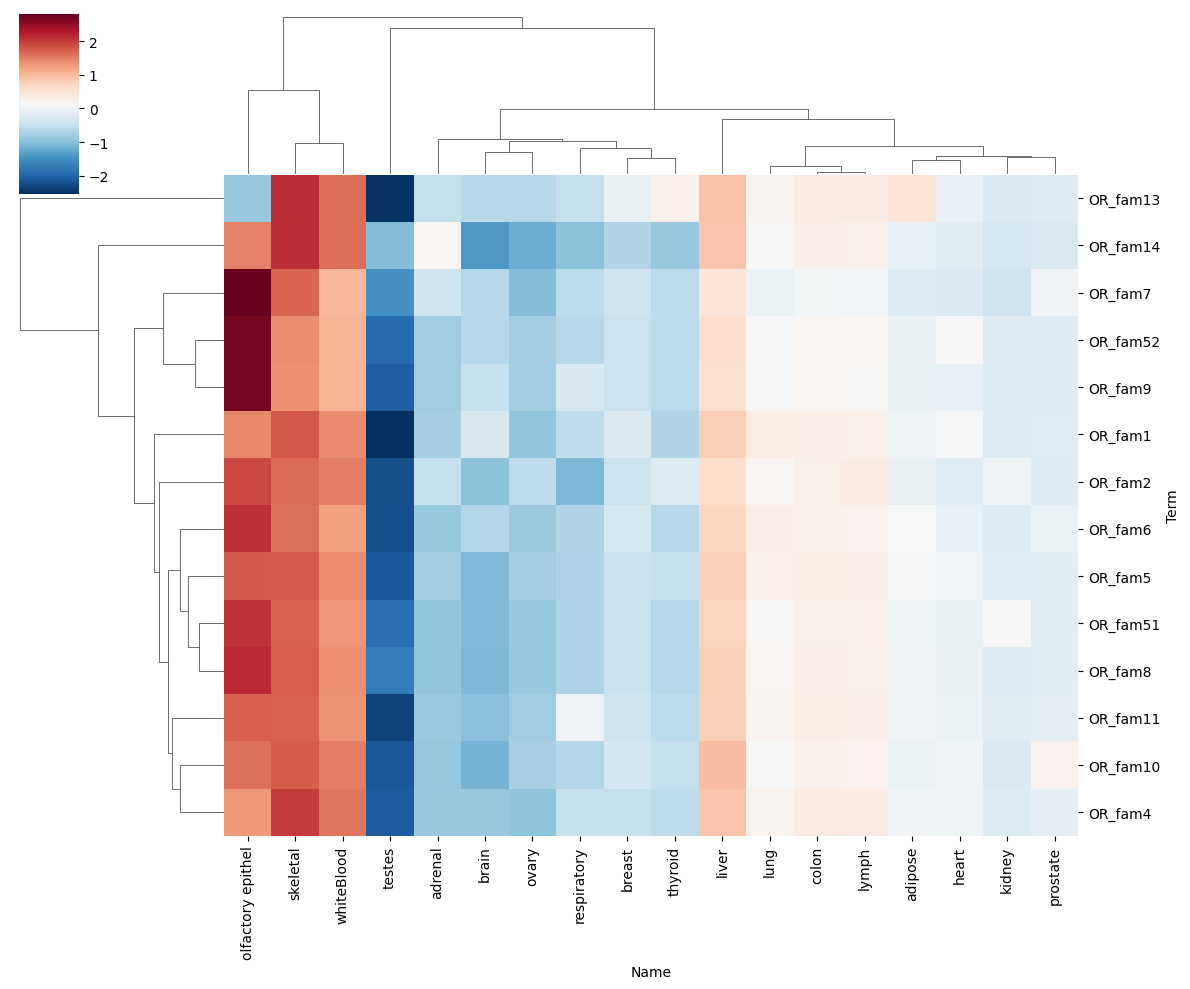

In [12]:
#heatmap

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    es_matrix,
    cmap        = "RdBu_r",
    z_score     = 0,
    figsize     = (12, 10),
    xticklabels = True
)

g.savefig("ssgsea_heatmap.png", dpi=300, bbox_inches="tight")

In [13]:
#data to csv format
es_matrix.to_csv("ssgsea_results.csv")

In [14]:
#download of data in csv format
from google.colab import files
files.download("ssgsea_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files
files.download("ssgsea_heatmap.png") #Export to png

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
g.savefig("ssgsea_heatmap.pdf", bbox_inches="tight")
files.download("ssgsea_heatmap.pdf") #Export to pdf

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>